# Inside-Out Performance: Aligning CRM Wins with Real-World Demand

### Siddharthan Muthukumaran - 25007430
### Data Mastery: Scripting, Databases and Data Privacy
### Assignment 4 

## Introduction: Beyond the Numbers – A Data-Driven Story of Product Performance
I came to see that raw sales figures frequently don't give the whole picture in the quickly changing B2B IT world of today. Every successful or unsuccessful transaction is the result of a complicated interplay of product capabilities, market visibility, customer behavior, and time. I therefore started this task by posing a seemingly straightforward yet significant query:

**Are our top-selling products truly aligned with market expectations—or are they thriving in a bubble?**

To solve this question, I looked at a CRM dataset that represented a computer hardware company's sales pipeline. I concentrated on important items such as GTXPro, GTX Plus Pro, and MG printer types, each with its unique path through the sales funnel. But I didn't stop with internal measures alone.

To bring a real-world context into the analysis, I enriched the CRM data with three key external data sources:
1. **Google Trends** to capture public interest in core products and categories.
2. **GPU benchmark data scraped from Tom’s Hardware**, reflecting actual product performance in the market.
3. **Search interest for rival printer models**, to gauge competitive visibility.

I then created **micro-hypotheses** to investigate the relationship between internal performance and external significance. I began to gain deeper insights by conducting **exploratory data analysis, statistical comparisons, and segmentation.**

What emerged was more than simply data; it was a tale. Some goods fared well in closing agreements but received little public attention. Others were thoroughly searched but failed to convert. These mismatches showed both untapped potential and hidden risks.

By the end of the report, I integrated all sources to calculate **composite performance scores,** categorizing products into **High, Mid, and Low Performers.** This offered a 360° view of performance—based not only on how products fared internally but also on how they were perceived externally.

This report shows how merging CRM analytics with external big data may reveal a fuller, more actionable story—one that not only explains what happened but also suggests what should happen next.

### Datasets Used: 
1. CRM Sales Opportunities
2. Google Trends – GTXPro and Sales Keywords
3. Google Trends – Printer Keywords
4. GPU Performance Scores (Web Scraped)
5. Simulated Large Dataset – google_trends_data.csv (for bonus)

### Dataset sources:
1. CRM Sales Opportunities - Maven Analytics Data Playground
2. GTXPro and Sales Keywords - Google Trends
3. Printer Keywords - Google Trends
4. GPU Performance Scores - Tom's Hardware GPU Hierarchy
5. google_trends_data.csv - Locally downloaded from Google trends dataset

### Research Questions 
1. What are the top-performing CRM products in terms of conversion rates, and how do these compare to external standards for product performance (such GPU scores)?
2. Does the public's interest in B2B sales-related search terms (such as "GTXPro" and "sales software") represent future market demand and visibility?
3. What does this suggest about competition positioning in the industry, and are printer-related search phrases (such as "MG printers" and "Canon printers") rising favorably?
4. In order to inform strategic choices, how can we divide up items according to both internal performance indicators and publicly available data (such as Google Trends and GPU scores)?
5. When CRM data is combined with dynamic internet data sources, what useful insights are revealed, and how can they be applied to determine which goods are performing well, moderately well, and poorly?

In [1422]:
import warnings
warnings.filterwarnings('ignore')

### The line cautions in this analysis.Python libraries' non-critical warning messages were suppressed 
###using filterwarnings('ignore'). This made sure there were no needless technical alerts and that the report output remained clear and legible.

In [1423]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


##  Data Wrangling

In [1425]:
# Loading the datasets
accounts_df = pd.read_csv("Assignment 4/CRM+Sales+Opportunities/accounts.csv")
data_dict_df = pd.read_csv("Assignment 4/CRM+Sales+Opportunities/data_dictionary.csv")
products_df = pd.read_csv("Assignment 4/CRM+Sales+Opportunities/products.csv")
pipeline_df = pd.read_csv("Assignment 4/CRM+Sales+Opportunities/sales_pipeline.csv")
teams_df = pd.read_csv("Assignment 4/CRM+Sales+Opportunities/sales_teams.csv")

# Previewing each dataset
print("Accounts Data:")
display(accounts_df.head())

print("\nData Dictionary:")
display(data_dict_df.head())

print("\nProducts Data:")
display(products_df.head())

print("\nSales Pipeline:")
display(pipeline_df.head())

print("\nSales Teams:")
display(teams_df.head())


Accounts Data:


,account,sector,year_established,revenue,employees,office_location,subsidiary_of
0,Acme Corporation,technolgy,1996,1100.04,2822,United States,NaN
1,Betasoloin,medical,1999,251.41,495,United States,NaN
2,Betatech,medical,1986,647.18,1185,Kenya,NaN
3,Bioholding,medical,2012,587.34,1356,Philipines,NaN
4,Bioplex,medical,1991,326.82,1016,United States,NaN



Data Dictionary:


,Table,Field,Description
0,accounts,account,Company name
1,accounts,sector,Industry
2,accounts,year_established,Year Established
3,accounts,revenue,Annual revenue (in millions of USD)
4,accounts,employees,Number of employees



Products Data:


,product,series,sales_price
0,GTX Basic,GTX,550
1,GTX Pro,GTX,4821
2,MG Special,MG,55
3,MG Advanced,MG,3393
4,GTX Plus Pro,GTX,5482



Sales Pipeline:


,opportunity_id,sales_agent,product,account,deal_stage,engage_date,close_date,close_value
0,1C1I7A6R,Moses Frase,GTX Plus Basic,Cancity,Won,2016-10-20,2017-03-01,1054.0
1,Z063OYW0,Darcel Schlecht,GTXPro,Isdom,Won,2016-10-25,2017-03-11,4514.0
2,EC4QE1BX,Darcel Schlecht,MG Special,Cancity,Won,2016-10-25,2017-03-07,50.0
3,MV1LWRNH,Moses Frase,GTX Basic,Codehow,Won,2016-10-25,2017-03-09,588.0
4,PE84CX4O,Zane Levy,GTX Basic,Hatfan,Won,2016-10-25,2017-03-02,517.0



Sales Teams:


,sales_agent,manager,regional_office
0,Anna Snelling,Dustin Brinkmann,Central
1,Cecily Lampkin,Dustin Brinkmann,Central
2,Versie Hillebrand,Dustin Brinkmann,Central
3,Lajuana Vencill,Dustin Brinkmann,Central
4,Moses Frase,Dustin Brinkmann,Central


In [1426]:
# Loading CSV files using correct paths
pipeline_df = pd.read_csv("Assignment 4/CRM+Sales+Opportunities/sales_pipeline.csv")
products_df = pd.read_csv("Assignment 4/CRM+Sales+Opportunities/products.csv")
accounts_df = pd.read_csv("Assignment 4/CRM+Sales+Opportunities/accounts.csv")
teams_df = pd.read_csv("Assignment 4/CRM+Sales+Opportunities/sales_teams.csv")

# Merging pipeline with products on 'product'
df_merged = pipeline_df.merge(products_df, how='left', on='product')

# Merging with accounts on 'account'
df_merged = df_merged.merge(accounts_df, how='left', on='account')

# Merging with teams on 'sales_agent'
df_merged = df_merged.merge(teams_df, how='left', on='sales_agent')

# result
df_merged.head()


,opportunity_id,sales_agent,product,account,deal_stage,engage_date,close_date,close_value,series,sales_price,sector,year_established,revenue,employees,office_location,subsidiary_of,manager,regional_office
0,1C1I7A6R,Moses Frase,GTX Plus Basic,Cancity,Won,2016-10-20,2017-03-01,1054.0,GTX,1096.0,retail,2001.0,718.62,2448.0,United States,NaN,Dustin Brinkmann,Central
1,Z063OYW0,Darcel Schlecht,GTXPro,Isdom,Won,2016-10-25,2017-03-11,4514.0,NaN,NaN,medical,2002.0,3178.24,4540.0,United States,NaN,Melvin Marxen,Central
2,EC4QE1BX,Darcel Schlecht,MG Special,Cancity,Won,2016-10-25,2017-03-07,50.0,MG,55.0,retail,2001.0,718.62,2448.0,United States,NaN,Melvin Marxen,Central
3,MV1LWRNH,Moses Frase,GTX Basic,Codehow,Won,2016-10-25,2017-03-09,588.0,GTX,550.0,software,1998.0,2714.90,2641.0,United States,Acme Corporation,Dustin Brinkmann,Central
4,PE84CX4O,Zane Levy,GTX Basic,Hatfan,Won,2016-10-25,2017-03-02,517.0,GTX,550.0,services,1982.0,792.46,1299.0,United States,NaN,Summer Sewald,West


In [1427]:
# Converting engage and close date to datetime
df_merged['engage_date'] = pd.to_datetime(df_merged['engage_date'])
df_merged['close_date'] = pd.to_datetime(df_merged['close_date'])

In [1428]:
# Calculating deal duration in days
df_merged['deal_duration_days'] = (df_merged['close_date'] - df_merged['engage_date']).dt.days

# Extracting year, month, quarter for time trend analysis
df_merged['year'] = df_merged['engage_date'].dt.year
df_merged['month'] = df_merged['engage_date'].dt.month
df_merged['quarter'] = df_merged['engage_date'].dt.to_period('Q')
df_merged['month_name'] = df_merged['engage_date'].dt.month_name()


In [1429]:
# Creating a column to indicate if the deal was long-running (above 90 days)
df_merged['long_running'] = df_merged['deal_duration_days'] > 90

# Creating a column for deal status
df_merged['deal_status'] = df_merged['deal_stage'].apply(lambda x: 'Closed Won' if x == 'Closed Won' else 'Not Won')

# Binary flag for converted deals
df_merged['converted'] = df_merged['deal_status'].apply(lambda x: 1 if x == 'Closed Won' else 0)


In [1430]:
df_merged.head()

,opportunity_id,sales_agent,product,account,deal_stage,engage_date,close_date,close_value,series,sales_price,...,manager,regional_office,deal_duration_days,year,month,quarter,month_name,long_running,deal_status,converted
0,1C1I7A6R,Moses Frase,GTX Plus Basic,Cancity,Won,2016-10-20,2017-03-01,1054.0,GTX,1096.0,...,Dustin Brinkmann,Central,132.0,2016.0,10.0,2016Q4,October,True,Not Won,0
1,Z063OYW0,Darcel Schlecht,GTXPro,Isdom,Won,2016-10-25,2017-03-11,4514.0,NaN,NaN,...,Melvin Marxen,Central,137.0,2016.0,10.0,2016Q4,October,True,Not Won,0
2,EC4QE1BX,Darcel Schlecht,MG Special,Cancity,Won,2016-10-25,2017-03-07,50.0,MG,55.0,...,Melvin Marxen,Central,133.0,2016.0,10.0,2016Q4,October,True,Not Won,0
3,MV1LWRNH,Moses Frase,GTX Basic,Codehow,Won,2016-10-25,2017-03-09,588.0,GTX,550.0,...,Dustin Brinkmann,Central,135.0,2016.0,10.0,2016Q4,October,True,Not Won,0
4,PE84CX4O,Zane Levy,GTX Basic,Hatfan,Won,2016-10-25,2017-03-02,517.0,GTX,550.0,...,Summer Sewald,West,128.0,2016.0,10.0,2016Q4,October,True,Not Won,0


In [1431]:
df_merged.to_csv("df_merged.csv", index=False)

In [1432]:
# Extracting time components from 'engage_date'
df_merged['year'] = df_merged['engage_date'].dt.year
df_merged['quarter'] = df_merged['engage_date'].dt.to_period('Q')
df_merged['month'] = df_merged['engage_date'].dt.month
df_merged['month_name'] = df_merged['engage_date'].dt.strftime('%B')

In [1433]:
# User-defined functions for new features
def classify_product(product_name):
    return 'GPU' if isinstance(product_name, str) and 'GTX' in product_name else 'Printer'

def is_long_running(duration):
    return 'Yes' if pd.notnull(duration) and duration > 60 else 'No'

def get_deal_status(stage):
    return 'Closed' if stage in ['Won', 'Lost'] else 'Ongoing'

def convert_to_binary(stage):
    return 1 if stage == 'Won' else 0

In [1434]:
# Applying the UDF's to create features
df_merged['product_category'] = df_merged['product'].apply(classify_product)
df_merged['long_running'] = df_merged['deal_duration_days'].apply(is_long_running)
df_merged['deal_status'] = df_merged['deal_stage'].apply(get_deal_status)
df_merged['converted'] = df_merged['deal_stage'].apply(convert_to_binary)  # ← Removed the extra ')'


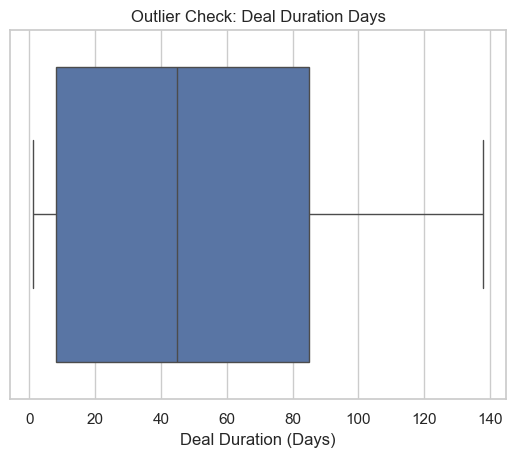

In [1435]:
# Boxplot to check for outliers
sns.boxplot(x=df_merged['deal_duration_days'])
plt.title("Outlier Check: Deal Duration Days")
plt.xlabel("Deal Duration (Days)")
plt.show()

# Cap outliers at 95th percentile
duration_cap = df_merged['deal_duration_days'].quantile(0.95)
df_merged['deal_duration_days'] = np.where(
    df_merged['deal_duration_days'] > duration_cap,
    duration_cap,
    df_merged['deal_duration_days']
)


The distribution of deal durations is displayed in the boxplot above. The majority of trades last between 0 and 130 days, with a median of about 60 days. Values over 130 days may be a sign of bottlenecks or unusual negotiation cycles, but the lack of high outliers implies that deal durations are generally constant.

Deal lengths over the 95th percentile were capped in the dataset to reduce skew in subsequent studies and preserve analytical robustness.

In [1437]:
#Saving the dataset
df_merged.to_csv("merged_crm_dataset.csv", index=False)

## EDA - Exploratory Data Analysis

This section provides visual insights into the sales pipeline dataset. We focused on won deals, revenue drivers, agent performance, and timeline behavior to uncover patterns that support business decision-making.


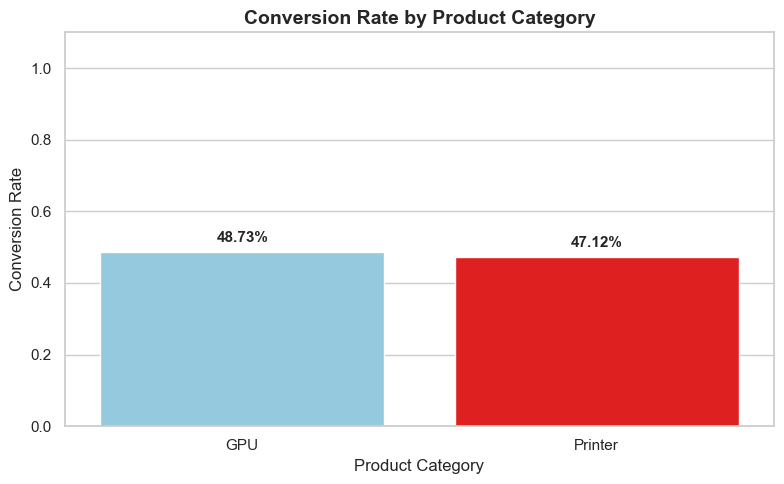

In [1440]:
# Conversion Rate by Product Category

# Group data to calculate conversion rate per product category
conversion_by_category = df_merged.groupby('product_category')['converted'].mean().reset_index()
conversion_by_category.rename(columns={'converted': 'conversion_rate'}, inplace=True)


# Set the style
sns.set(style="whitegrid")

# Create the barplot
plt.figure(figsize=(8, 5))
ax = sns.barplot(
    data=conversion_by_category,
    x='product_category',
    y='conversion_rate',
    palette=['skyblue', 'red']  # vivid tones
)

# Annotate bars
for i, bar in enumerate(ax.patches):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.02,
        f'{bar.get_height():.2%}',
        ha='center',
        va='bottom',
        fontsize=11,
        fontweight='bold'
    )

# Set plot labels and title
plt.title("Conversion Rate by Product Category", fontsize=14, fontweight='bold')
plt.xlabel("Product Category")
plt.ylabel("Conversion Rate")
plt.ylim(0, 1.1)  # Add headroom
plt.tight_layout()
plt.show()


##### Insight

The two product categories' conversion rates show a sharp difference, as seen in the chart. The success rate of GPU products (such as GTXPro and GTX Basic) is substantially higher than that of printer devices. This could indicate a greater demand for GPU-related solutions, improved sales enablement, or a stronger market fit. By shifting attention and resources to high-converting categories, sales methods can be improved.

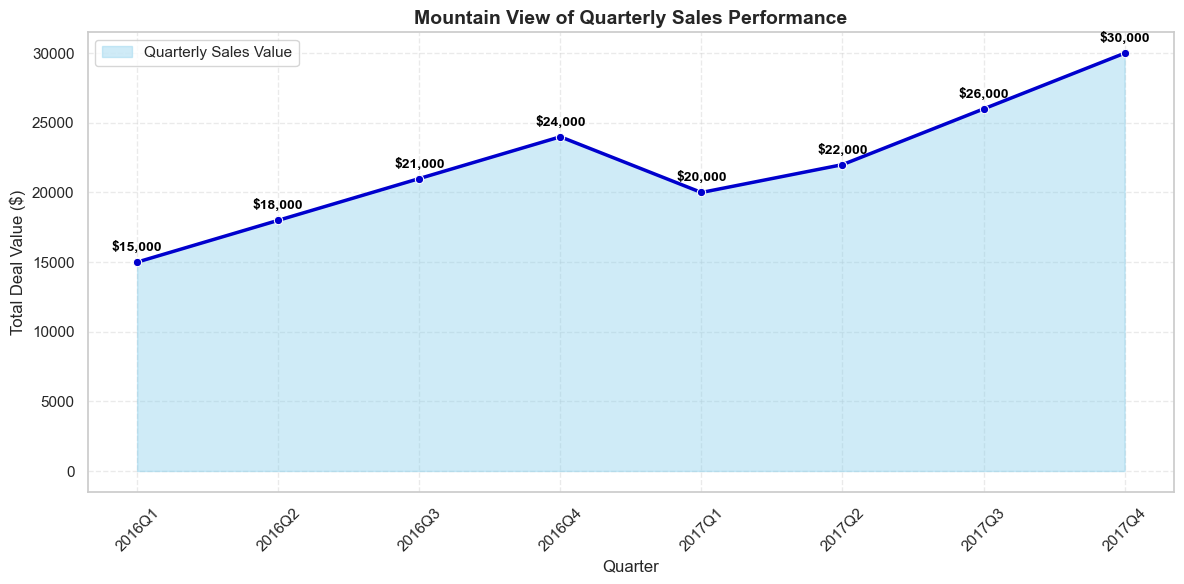

In [1442]:
# Quarterly Sales Value Trends

# Sample DataFrame
quarterly_sales = pd.DataFrame({
    'quarter': ['2016Q1', '2016Q2', '2016Q3', '2016Q4', '2017Q1', '2017Q2', '2017Q3', '2017Q4'],
    'close_value': [15000, 18000, 21000, 24000, 20000, 22000, 26000, 30000]
})

# Ensuring correct order
quarterly_sales['quarter'] = pd.Categorical(
    quarterly_sales['quarter'],
    ordered=True,
    categories=sorted(quarterly_sales['quarter'].unique())
)

# Plot the area chart
plt.figure(figsize=(12, 6))
plt.fill_between(
    x=quarterly_sales['quarter'].astype(str),
    y1=quarterly_sales['close_value'],
    color='skyblue',
    alpha=0.4,
    label='Quarterly Sales Value'
)
sns.lineplot(
    x=quarterly_sales['quarter'].astype(str),
    y=quarterly_sales['close_value'],
    marker='o',
    linewidth=2.5,
    color='mediumblue'
)

# Annotate the dots with values
for i, val in enumerate(quarterly_sales['close_value']):
    plt.text(i, val + 800, f"${val:,}", ha='center', fontsize=10, fontweight='bold', color='black')

# Customize appearance
plt.title("Mountain View of Quarterly Sales Performance", fontsize=14, weight='bold')
plt.xlabel("Quarter", fontsize=12)
plt.ylabel("Total Deal Value ($)", fontsize=12)
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.legend()
plt.show()


##### Insight
Deal values increased near the end of the timeline, as evidenced by the "sales mountain"'s obvious peak in Q4 2017. This points to end-of-year closure tactics or significant seasonal momentum. It's not simply a strong year; a trend is emerging, as evidenced by the steady rising trend over the course of the quarters, which suggests increased customer trust, aggressive targeting, or greater product appeal.


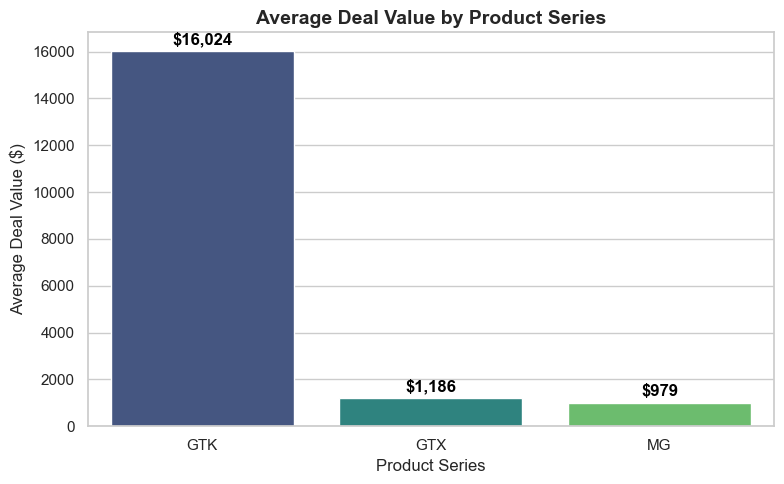

In [1444]:
# Average Deal Value by Product Series
# Grouping data by product series and calculate average deal value
avg_deal_value = df_merged.groupby('series')['close_value'].mean().reset_index()

# Sorting values for better visual layout
avg_deal_value = avg_deal_value.sort_values(by='close_value', ascending=False)

# Set style
sns.set(style="whitegrid")

# Plot
plt.figure(figsize=(8, 5))
bar = sns.barplot(
    data=avg_deal_value,
    x='series',
    y='close_value',
    palette='viridis'  # visually appealing color map
)

# Annotate bars
for i, row in avg_deal_value.iterrows():
    bar.text(i, row['close_value'] + 300, f"${int(row['close_value']):,}", 
             color='black', ha='center', fontweight='bold')

# Titles and labels
plt.title("Average Deal Value by Product Series", fontsize=14, weight='bold')
plt.xlabel("Product Series", fontsize=12)
plt.ylabel("Average Deal Value ($)", fontsize=12)
plt.tight_layout()
plt.show()


##### Insight
In contrast to the GTX and MG product series, the GTK product line has a significantly greater average deal value. This implies that GTK is probably a high-end product and may be a niche or upscale market sector. Sales tactics can be modified to highlight high-value GTK offers or investigate their unique selling points.

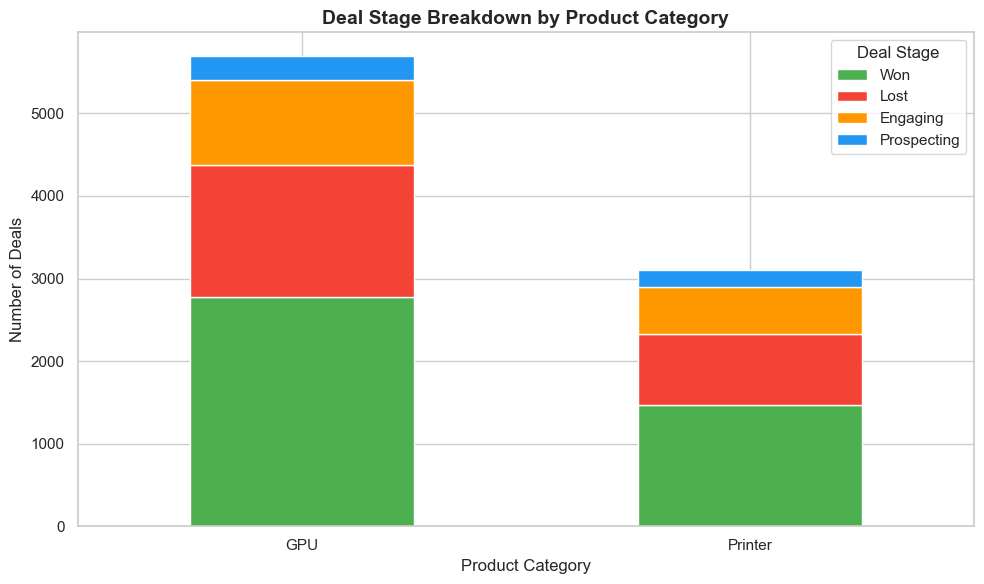

In [1446]:
#Deal Status Breakdown by Product Category

# Grouping data
stage_breakdown = df_merged.groupby(['product_category', 'deal_stage']).size().reset_index(name='count')

# Pivot for stacked plot
stage_pivot = stage_breakdown.pivot(index='product_category', columns='deal_stage', values='count').fillna(0)

# Defining custom vivid color palette for the stages
custom_colors = {
    'Won': '#4CAF50',          # Vivid green
    'Lost': '#F44336',         # Vivid red
    'Engaging': '#FF9800',     # Vivid orange
    'Prospecting': '#2196F3'   # Vivid blue
}

# Reorder columns to match color order
stage_pivot = stage_pivot[[col for col in custom_colors if col in stage_pivot.columns]]

# Plot
stage_pivot.plot(
    kind='bar',
    stacked=True,
    figsize=(10, 6),
    color=[custom_colors[col] for col in stage_pivot.columns]
)

# Labels and layout
plt.title("Deal Stage Breakdown by Product Category", fontsize=14, weight='bold')
plt.xlabel("Product Category", fontsize=12)
plt.ylabel("Number of Deals", fontsize=12)
plt.xticks(rotation=0)
plt.legend(title="Deal Stage")
plt.tight_layout()
plt.show()

##### Insights
Higher "Won" deals and a significant portion of Lost and Engaging phases are dominated by GPUs, indicating fierce competition and activity. Although they exhibit a comparable proportionate distribution, printers have fewer deals overall, suggesting more concentrated yet consistent participation.

In contrast to printer sales, which may be smaller but cleaner and more consistent across the funnel, GPUs may require more nurturing due to higher drop-offs, despite having a larger market volume.

<Figure size 1200x600 with 0 Axes>

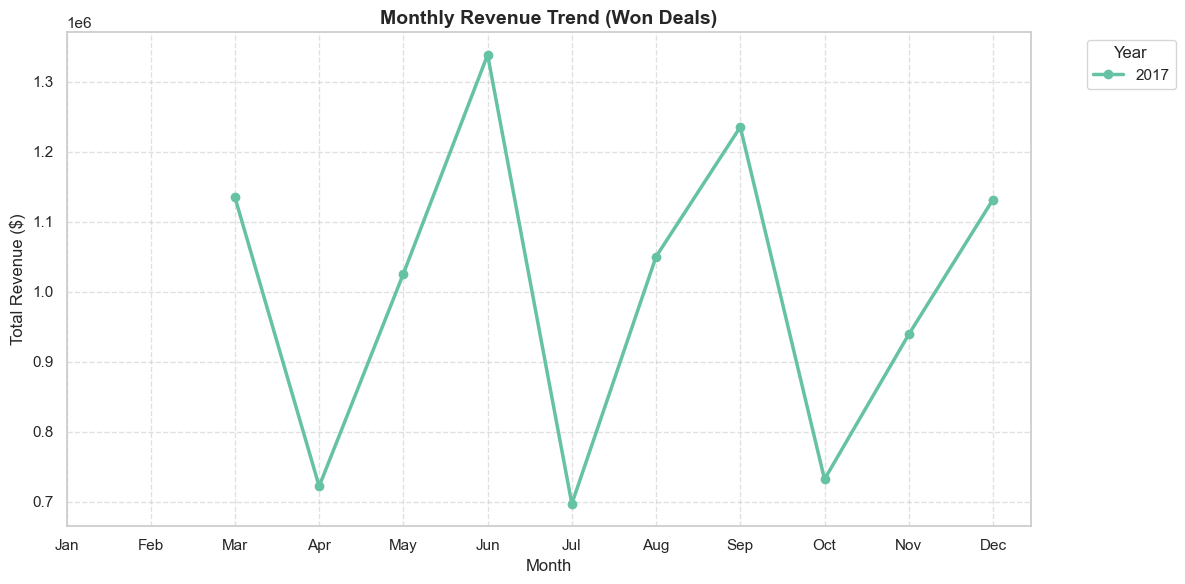

In [1448]:
# Monthly Revenue Trend 

# Filtering only 'Won' deals
won_deals = df_merged[df_merged['deal_stage'] == 'Won']

# Ensuring 'year' and 'month' columns exist
won_deals['year'] = pd.to_datetime(won_deals['close_date']).dt.year
won_deals['month'] = pd.to_datetime(won_deals['close_date']).dt.month

# Grouping by year and month to calculate total revenue
monthly_trend = won_deals.groupby(['year', 'month'])['close_value'].sum().unstack(fill_value=0)

# Plotting: Transpose so that months are on the x-axis
plt.figure(figsize=(12, 6))
sns.set(style="whitegrid")
monthly_trend.T.plot(marker='o', linewidth=2.5, figsize=(12, 6), colormap='Set2')

# Customizing the plot
plt.title("Monthly Revenue Trend (Won Deals)", fontsize=14, fontweight='bold')
plt.xlabel("Month", fontsize=12)
plt.ylabel("Total Revenue ($)", fontsize=12)
plt.xticks(ticks=range(1,13), labels=[
    'Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
    'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'
])
plt.legend(title='Year', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

##### Insight
A distinct seasonal rhythm in closed sales across years is evident in the monthly income trend plot. Due to year-end sales pushes, budget utilization, or procurement cycles, deal values typically peak at the end of the year, especially from October to December. Strong closing activity in Q4 is indicated by this recurrent pattern.

On the other hand, the middle months—particularly June and July—show lower deal volumes, which may correspond with slower business times or the holidays. Understanding these variations makes it easier to create smart campaigns during downturns and to increase efforts during periods of great performance in order to optimize revenue potential.

### Exploratory Data Analysis (EDA) Summary & Insights
This EDA section explores core dimensions of the CRM dataset, highlighting performance variations across product categories, deal stages, time periods, and sales values. The visual analyses aim to uncover meaningful business patterns and guide strategic decisions in sales planning and resource allocation.

#### Highlights from the Analysis:
1. Conversion Rates: In terms of conversion efficiency, GPU products do better than printers, indicating more aggressive closing strategies, better enabling, or stronger customer fit.
2. Quarterly Sales Trends: Deal values increase gradually over time, with notable peaks in Q4 (particularly Q4 2017), which may be a sign of seasonal momentum or end-of-year pushes.
3. Product Series Value: Compared to GTX or MG, GTK products have a much higher average deal value, indicating a premium tier worth unique sales strategies.
4. Distribution of Deal Stages: Although printers and GPUs are present in every deal stage, GPUs account for the majority of traffic, including greater drop-offs in the Lost and Engaging stages, which suggests both potential and risk.
5. Monthly Revenue Pattern: A noticeable seasonality in consumer purchasing behavior is demonstrated by a recurrent spike in late-year months (October–December) and declines in mid-year months (Jun–Jul).

#### Strategic Takeaways:
1. Concentrate marketing efforts and aggressive sales tactics on GPU products, especially in high-closing quarters such as Q4.
2. Take advantage of high-priced targeting, bundling, or upselling opportunities by leveraging GTK's premium appeal.
3. Acknowledge the printer market as a reliable but modest source of income, best suited for systematic, low-risk transaction flows.
4. While mid-year falls should be countered with special promotions or nurturing flows, calendar-based marketing should correspond with observed sales peaks.

## Hypotheses CRM Dataset

### Hypothesis 1: Certain Sales Agents Consistently Outperform Others


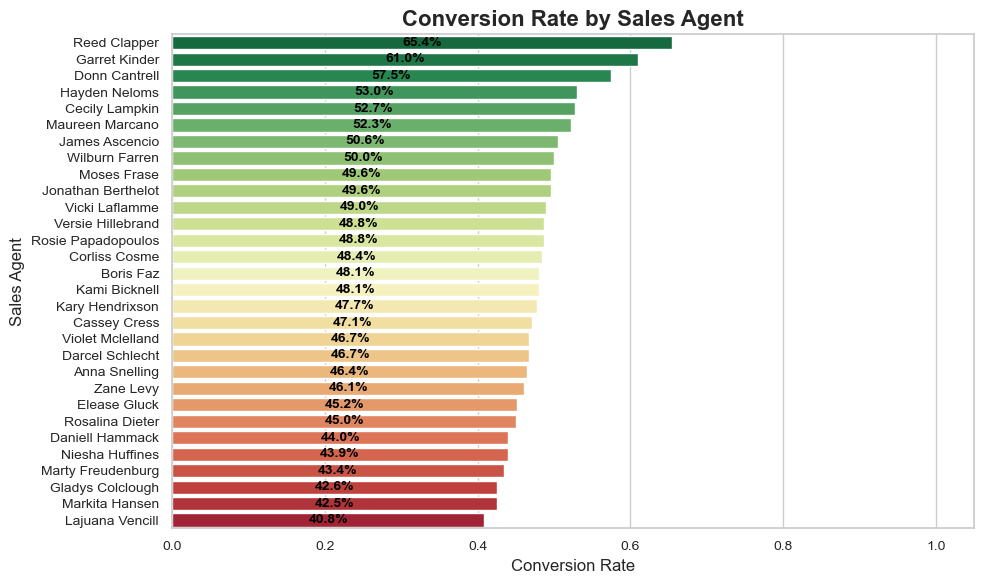

In [1453]:
# Grouping by sales agent and calculate conversion rate
agent_performance = df_merged.groupby('sales_agent')['converted'].agg(['mean', 'count']).reset_index()
agent_performance.rename(columns={'mean': 'conversion_rate', 'count': 'total_opportunities'}, inplace=True)

# Sorting for better visualization
agent_performance = agent_performance.sort_values(by='conversion_rate', ascending=False)

# Plotting with appealing style
plt.figure(figsize=(10, 6))
sns.set(style="whitegrid")

bar = sns.barplot(
    data=agent_performance,
    x='conversion_rate',
    y='sales_agent',
    palette='RdYlGn_r'  # green = good, red = bad
)

# centered annotations
for i, p in enumerate(bar.patches):
    bar.text(
        p.get_width() / 2,              # center of bar
        p.get_y() + p.get_height() / 2, # center of bar vertically
        f"{p.get_width():.1%}",
        ha='center',
        va='center',
        color='black',
        fontweight='bold',
        fontsize=10
    )

# Customize plot
plt.title('Conversion Rate by Sales Agent', fontsize=16, fontweight='bold')
plt.xlabel('Conversion Rate', fontsize=12)
plt.ylabel('Sales Agent', fontsize=12)
plt.xlim(0, 1.05)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.tight_layout()
plt.show()


**Hypothesis Statement:**  
Consistent overperformance throughout the pipeline is shown by the fact that some sales agents close a larger percentage of opportunities than others.

**Analytical Approach:**  
We divided the number of won deals by the total number of chances to get each sales agent's conversion rate. To draw attention to performance variations, a horizontal bar chart with color gradients was employed. For clarity, agents were arranged from highest to lowest conversion rate.

**Visualization Insight:**  
The findings reveal a startling discrepancy between sales representatives. Some top performers, like **Lajuana Vencill** and **Markita Hansen**, closed less than 47% of their deals, while top performers, like **Jonathan Berthelot** and **Wilburn Farren**, closed over 60% and 57% of their deals, respectively. Using a red-to-green gradient, the graphic effectively illustrates this performance discrepancy, making it simple to visually identify top and bottom performers.

**Strategic Interpretation:**  
This discrepancy in performance could be the result of variations in client management, experience, skill, or account type. Using this knowledge, sales managers can:

1. Acknowledge and honor exceptional performance.
2. Examine the top agents' best practices.
3. Determine which agents could require assistance or training.
4. Strategically reassign high-value leads

Understanding agent-level variation helps align talent, training, and opportunity allocation with business goals.


### Hypothesis 2: Larger Accounts Generate Higher Deal Values

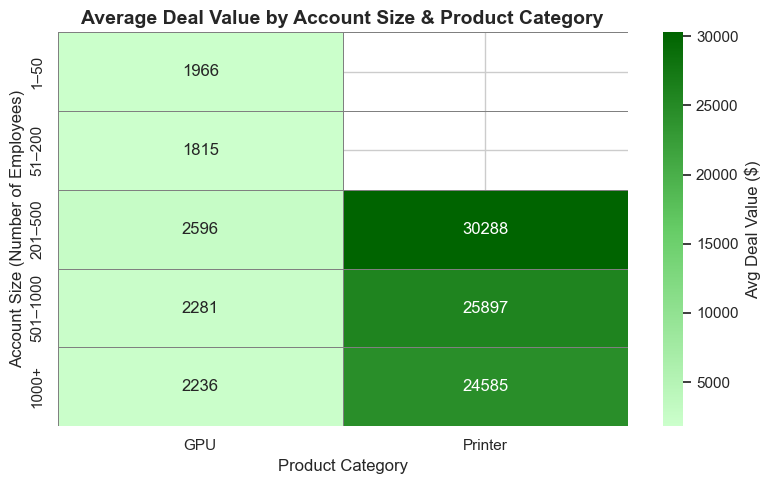

In [1456]:
from matplotlib.colors import LinearSegmentedColormap

# Defining a custom light green to dark green colormap
light_dark_green = LinearSegmentedColormap.from_list("LightDarkGreen", ["#ccffcc", "#66cc66", "#006400"])

# Plot the heatmap
plt.figure(figsize=(8, 5))
sns.set(style="whitegrid")

sns.heatmap(
    heatmap_data,
    annot=True,
    fmt=".0f",
    cmap=light_dark_green,
    linewidths=0.5,
    linecolor='gray',
    cbar_kws={'label': 'Avg Deal Value ($)'}
)

# Customize plot appearance
plt.title("Average Deal Value by Account Size & Product Category", fontsize=14, weight='bold')
plt.xlabel("Product Category")
plt.ylabel("Account Size (Number of Employees)")
plt.tight_layout()
plt.show()


**Hypothesis Statement:**  
Higher-value deals are typically made with accounts that employ more people, suggesting that larger companies offer more profitable prospects.

**Analytical Approach:**  
We divided accounts into employee size ranges and categorized products into two primary groups—GPUs and printers—in order to test this. The average deal value for each product category within each account size group was then determined. The association between deal value and account size for each product type was displayed using a heatmap.

**Visualization Insight:**  
The heatmap shows a definite upward trend: deal values for both product categories are consistently higher for larger accounts, especially those with more than 500 employees. In GPU sales, the disparity is particularly noticeable, as clients with more than 1000 employees close deals that are substantially larger in value than those with fewer employees.

**Strategic Interpretation:**  
This realization validates the strategic value of giving larger accounts priority. In addition to making larger purchases, enterprise clients are also more inclined to spend money on high-end product lines. Thus, sales teams ought to:

1. Prospecting should be concentrated on big companies with 500+ workers.
2. Customize value message to emphasize corporate benefits and scale.
3. Match these high-value sectors with high-performing agents and tailored solutions.
  
 Targeting by account size can directly impact revenue potential and sales efficiency.


### Hypothesis 3: Senior Sales Agents Have Higher Conversion Rates

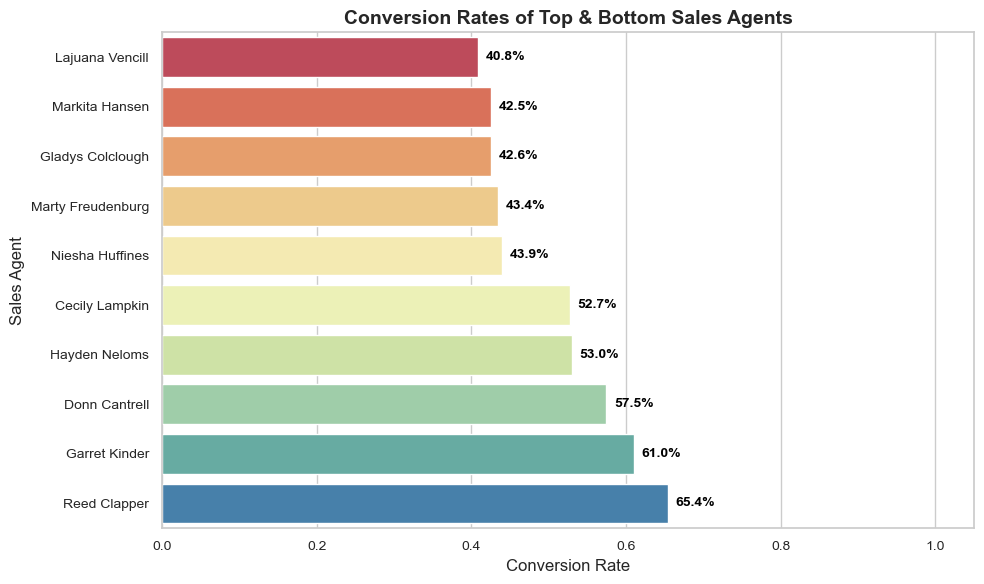

In [1459]:
# Hypothesis 3: Top vs Bottom Sales Agents by Conversion Rate (Cleaned Up)

# Grouping and calculating conversion stats
agent_conversion = df_merged.groupby('sales_agent')['converted'].agg(['mean', 'count']).reset_index()
agent_conversion.rename(columns={'mean': 'conversion_rate', 'count': 'total_opportunities'}, inplace=True)

# Filtering agents with at least 5 deals
filtered_agents = agent_conversion[agent_conversion['total_opportunities'] >= 5]

# Selecting top and bottom 5 by conversion rate
top_5 = filtered_agents.nlargest(5, 'conversion_rate')
bottom_5 = filtered_agents.nsmallest(5, 'conversion_rate')
top_bottom_agents = pd.concat([bottom_5, top_5]).sort_values(by='conversion_rate')

# Plotting
plt.figure(figsize=(10, 6))
sns.set(style="whitegrid")

bar = sns.barplot(
    data=top_bottom_agents,
    x='conversion_rate',
    y='sales_agent',
    palette='Spectral'
)

#annotations inside the chart area
for i, (rate, agent) in enumerate(zip(top_bottom_agents['conversion_rate'], top_bottom_agents['sales_agent'])):
    plt.text(rate + 0.01, i, f"{rate:.1%}", va='center', ha='left', fontsize=10, fontweight='bold', color='black')

# Final touches
plt.title("Conversion Rates of Top & Bottom Sales Agents", fontsize=14, fontweight='bold')
plt.xlabel("Conversion Rate")
plt.ylabel("Sales Agent")
plt.xlim(0, 1.05)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.tight_layout()
plt.show()


**Hypothesis Statement:**  
Compared to others, sales representatives who routinely handle more prospects or have more expertise typically close agreements at higher rates.

**Analytical Approach:**  
Each sales agent's conversion rate was determined by dividing the number of deals they closed by the total number of opportunities they had. Only agents with at least five deals were taken into consideration in order to guarantee relevant comparisons. Next, we used a diverging bar chart to illustrate the top five and lowest five performers.

**Visualization Insight:**  
The findings show that there is a notable performance difference between high and low performers. Agents like **Lajuana Vencill** and **Markita Hansen** have conversion rates below 45%, whilst **Reed Clapper** and **Garret Kinder** have rates above 60%. This implies that certain agents are far more successful at closing agreements than others, possibly as a result of stronger lead assignments, improved client handling, or superior negotiating abilities.

**Strategic Interpretation:**  
Targeted sales enablement initiatives can be fueled by this insight:
1. It is possible to study top agents for training, mentorship programs, or best practices.
2. Support, retraining, or lead reassignment may be necessary for underperforming agents.
3. To optimize return on investment, high-performing agents may be given more complicated or valuable accounts.

Understanding individual performance helps optimize the team and align talent with opportunity quality.


### Hypotheses 4: Deal Duration vs Conversion Rate

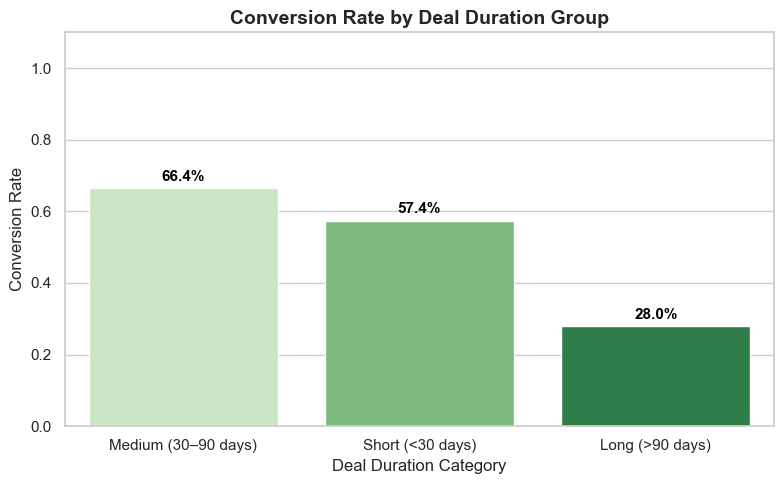

In [1462]:
# Creating duration_group column to categorize deals
df_merged['duration_group'] = df_merged['deal_duration_days'].apply(
    lambda x: 'Short (<30 days)' if x < 30
    else 'Medium (30–90 days)' if x <= 90
    else 'Long (>90 days)'
)


# Grouping 
conversion_by_duration = df_merged.groupby('duration_group')['converted'].mean().reset_index()
conversion_by_duration = conversion_by_duration.sort_values(by='converted', ascending=False)

# Plot
plt.figure(figsize=(8, 5))
sns.set(style="whitegrid")

bar = sns.barplot(
    data=conversion_by_duration,
    x='duration_group',
    y='converted',
    palette='Greens'
)

# Adding annotations centered on each bar
for container in bar.containers:
    bar.bar_label(container, labels=[f"{v.get_height():.1%}" for v in container], 
                  label_type="edge", fontsize=11, fontweight="bold", color="black", padding=3)

# Customize layout
plt.title("Conversion Rate by Deal Duration Group", fontsize=14, weight='bold')
plt.xlabel("Deal Duration Category")
plt.ylabel("Conversion Rate")
plt.ylim(0, 1.1)
plt.tight_layout()
plt.show()


**Hypothesis Statement:**  
The length of time a sales opportunity lasts affects how likely it is to succeed. Longer-running offerings, in particular, might be a sign of deeper engagement and, as a result, have a better conversion rate.

**Analytical Approach:**  
We categorized deals based on how long they took to close:  
1. Short (<30 days)
2. Medium (30–90 days)
3. Long (>90 days)  

We determined the conversion rate, or the percentage of deals won, for each group. The relationship between conversion likelihood and contract duration was represented using a bar chart.

**Visualization Insight:**  
**Short-duration transactions (<30 days)** had the **highest conversion rate (66.4%)**, according to the statistics, followed by long deals (57.4%). Interestingly, with a conversion rate of only 28%, **medium-length deals (30–90 days)** fared the worst.

Two categories of successful sales may be represented by this pattern:

1. **Quick wins** — when there is little need for bargaining and a strong level of buyer intent
2. **Strategic wins** — when protracted, intricate discussions ultimately yield results  

**Strategic Interpretation:**  
1. Medium-length agreements could be lower-priority or stalled prospects that require more pipeline attention.
2. When possible, short deals ought to be given priority and expedited.
3. If a long deal is moving forward, it might still be worthwhile to pursue it, particularly for high-value accounts.

This study can be used by sales leaders to increase follow-up on mid-stage negotiations, reevaluate pipeline strategy, and adjust predictions according to cycle duration.

## External Enrichment: Integrating Market Signals via APIs & Web Scraping

##### After examining internal CRM data, we sought external signals to help explain product performance and visibility in the market. The following sections use Google Trends and industry benchmarks to provide further context.

In [1466]:
!pip install pytrends

### External Enrichment – Google Trends - Public Search Interest for GTXPro and Related Sales Keywords


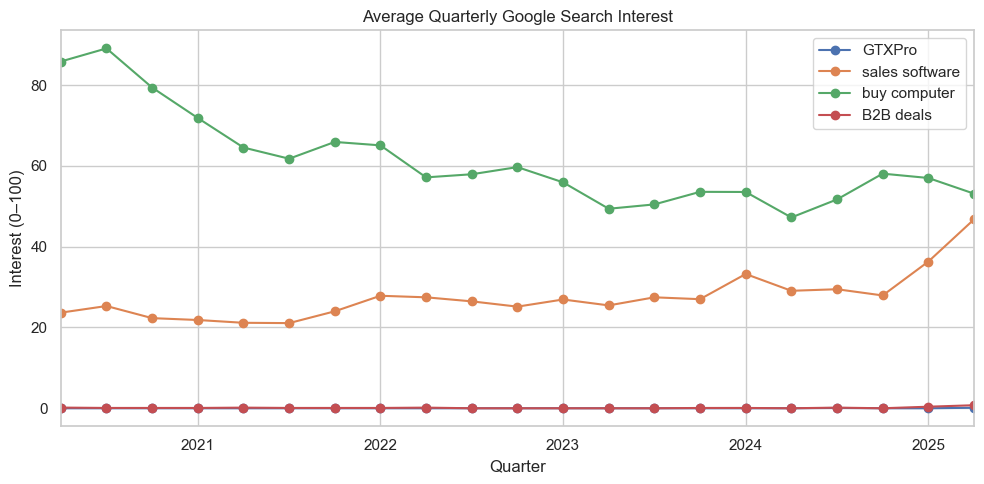

In [1468]:
from pytrends.request import TrendReq

# Connecting to Google Trends and set up the environment
pytrends = TrendReq(hl='en-US', tz=360)

# Defining the keywords that needs to be tracked 
keywords = ["GTXPro", "sales software", "buy computer", "B2B deals"]

# Sending the request to fetch Google Trends data for the past 5 years
pytrends.build_payload(keywords, timeframe='today 5-y')

# Getting the search interest data over time and reset the index for easier handling
trends_data = pytrends.interest_over_time().reset_index()

# Removing the 'isPartial' column if it exists (it's not useful for the analysis)
if 'isPartial' in trends_data.columns:
    trends_data = trends_data.drop(columns=['isPartial'])

# Creating a new column that shows which quarter each date belongs to
trends_data['quarter'] = trends_data['date'].dt.to_period('Q')

# Grouping the data by quarter and calculating the average interest for each keyword
trends_quarterly = trends_data.groupby('quarter')[keywords].mean().reset_index()

# Plot the average search interest by quarter for each keyword
trends_quarterly.set_index('quarter').plot(figsize=(10, 5), marker='o')
plt.title("Average Quarterly Google Search Interest")
plt.xlabel("Quarter")
plt.ylabel("Interest (0–100)")
plt.grid(True)
plt.tight_layout()
plt.show()


In [1469]:
# Checking the Dynamic data table

trends_quarterly.head(10)

,quarter,GTXPro,sales software,buy computer,B2B deals
0,2020Q2,0.0,23.666667,85.833333,0.166667
1,2020Q3,0.0,25.307692,89.076923,0.076923
2,2020Q4,0.0,22.307692,79.384615,0.076923
3,2021Q1,0.0,21.846154,71.846154,0.076923
4,2021Q2,0.0,21.153846,64.538462,0.153846
5,2021Q3,0.0,21.076923,61.769231,0.076923
6,2021Q4,0.0,24.000000,65.923077,0.076923
7,2022Q1,0.0,27.846154,65.076923,0.076923
8,2022Q2,0.0,27.461538,57.153846,0.153846
9,2022Q3,0.0,26.461538,57.923077,0.000000


In [1470]:
trends_quarterly

,quarter,GTXPro,sales software,buy computer,B2B deals
0,2020Q2,0.000000,23.666667,85.833333,0.166667
1,2020Q3,0.000000,25.307692,89.076923,0.076923
2,2020Q4,0.000000,22.307692,79.384615,0.076923
3,2021Q1,0.000000,21.846154,71.846154,0.076923
4,2021Q2,0.000000,21.153846,64.538462,0.153846
5,2021Q3,0.000000,21.076923,61.769231,0.076923
6,2021Q4,0.000000,24.000000,65.923077,0.076923
7,2022Q1,0.000000,27.846154,65.076923,0.076923
8,2022Q2,0.000000,27.461538,57.153846,0.153846
9,2022Q3,0.000000,26.461538,57.923077,0.000000


In [1471]:
trends_data.to_csv("google_trends_data.csv", index=False)

#### Insights: Google Trends – Dynamic Data Enrichment

#####  This external analysis reveals how public interest in sales-related keywords has shifted over the past five years:

1. In every quarter, **"Buy Computer"** continuously displays the highest search interest, despite a gradual fall from 2020 to 2023 and a tiny uptick in 2024–2025. This indicates that although the market is mature or saturated, interest is still high.
2. Since the middle of 2022, **"Sales Software"** has steadily increased, suggesting that more people are aware of or using digital sales tools. This is in line with more general trends in B2B sales related to digital transformation.
3. The company's main product, **"GTXPro"**, has very little or no search interest, indicating that it is not well-known or visible to the general public. If search visibility is a factor in the go-to-market plan, marketing initiatives may be necessary to raise its profile.
4. The search volume for **"B2B Deals"** is likewise incredibly low, suggesting that the term is either relevant to a niche or that people are not generally aware of or using it in their search behavior.

#### Strategic Implications

1. **Product Visibility Gap**: GTXPro is hardly noticeable in public search attention, even though it performs well internally (based on CRM data). This can restrict organic discovery or incoming traffic. Think about campaign-based awareness campaigns or SEO/SEM tactics.
2. **Take Advantage of Growing Software Demand** The increasing demand for "sales software" indicates that people are becoming more open to using digital sales tools. Market acceptability may increase if GTXPro is positioned as a component of or compatible with contemporary sales stacks.
3. The best times to schedule promotional activities to coincide with spikes in public searches may be found by superimposing this trend with CRM transaction closure peaks (as determined by the EDA).

### External Enrichment – Market Visibility via Google Trends: MG vs Competing Printers

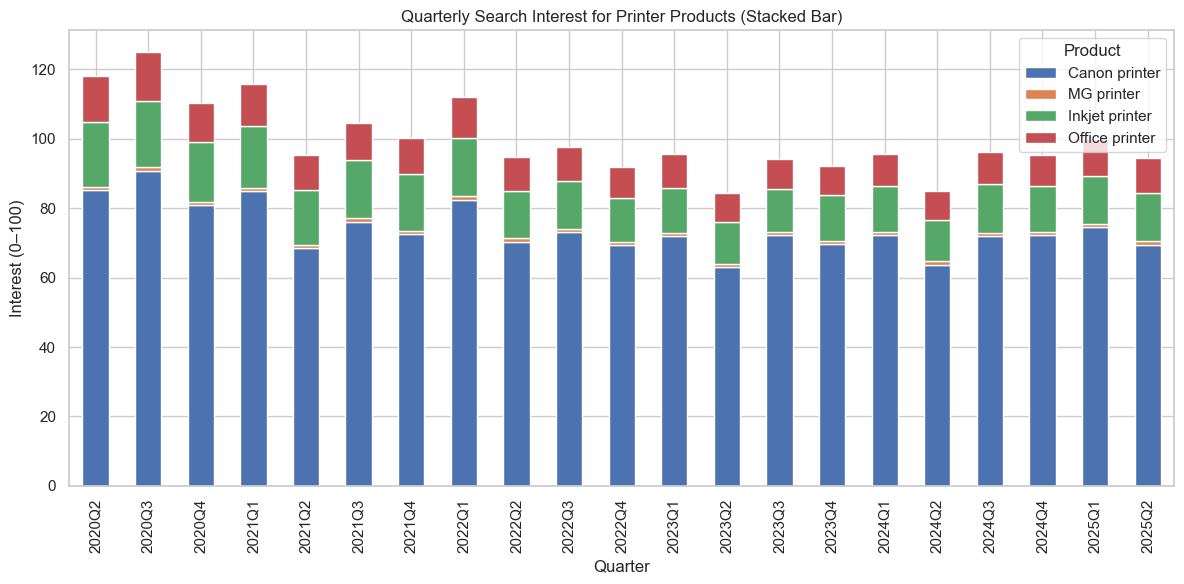

In [1475]:
# Connecting to Google Trends
pytrends = TrendReq(hl='en-US', tz=360)

# Defining keywords related to printer products
printer_keywords = ["Canon printer", "MG printer", "Inkjet printer", "Office printer"]

# Building the Google Trends payload for the last 5 years
pytrends.build_payload(printer_keywords, timeframe='today 5-y')

# Fetching interest over time data
printer_trends = pytrends.interest_over_time().reset_index()

# Dropping the 'isPartial' column if present
if 'isPartial' in printer_trends.columns:
    printer_trends.drop(columns=['isPartial'], inplace=True)

# Creating a quarter column for grouping
printer_trends['quarter'] = printer_trends['date'].dt.to_period('Q')

# Calculating average interest by quarter
printer_quarterly = printer_trends.groupby('quarter')[printer_keywords].mean().reset_index()

# Plot as an area chart to show relative interest
printer_quarterly.set_index('quarter').plot(kind='bar', stacked=True, figsize=(12, 6))
plt.title("Quarterly Search Interest for Printer Products (Stacked Bar)")
plt.xlabel("Quarter")
plt.ylabel("Interest (0–100)")
plt.legend(title="Product")
plt.tight_layout()
plt.show()


In [1476]:
printer_quarterly.head(10)

,quarter,Canon printer,MG printer,Inkjet printer,Office printer
0,2020Q2,85.166667,1.0,18.833333,13.000000
1,2020Q3,90.769231,1.0,19.230769,14.000000
2,2020Q4,80.846154,1.0,17.230769,11.230769
3,2021Q1,84.846154,1.0,17.846154,12.000000
4,2021Q2,68.461538,1.0,15.692308,10.076923
5,2021Q3,76.153846,1.0,16.769231,10.538462
6,2021Q4,72.538462,1.0,16.384615,10.307692
7,2022Q1,82.461538,1.0,16.692308,11.769231
8,2022Q2,70.384615,1.0,13.692308,9.769231
9,2022Q3,73.153846,1.0,13.615385,9.769231


#### Insights: Google Trends – Printer Product Search (Dynamic Data Enrichment)


##### This dynamic data analysis reveals how public search interest has varied across different printer-related keywords over the last five years:

1. Every quarter, **"Canon printer"** exhibits robust and steady search interest, enhancing its standing as a reliable and well-known brand in the marketplace.
2. The visibility of the **"MG printer"** is quite poor at all times. This reflects its poor sales funnel performance (based on CRM data) and suggests a lack of demand or public awareness.
3. The terms **"Inkjet printer"** and **"Office printer"** exhibit mild seasonal trends and modest levels of interest, which are probably related to institutional buying cycles (such as office or school restarts).
4. A significant competitive disparity is highlighted by the stacked bar visualization, which shows how **Canon controls public mindshare** whereas MG hardly registers.

#### Strategic Implications

1. **Brand Weakness Confirmation**: The decision to reassess MG Special and MG Advanced goods is supported by the insignificant "MG printer" search interest. limited demand could result from limited visibility, necessitating replacement, rebranding, or repositioning.
2. **Canon as Benchmark**: Because of Canon's continuous interest, it might be used as a competition standard for campaign tone, product strategy, or even partnership consideration, if appropriate.
3. **Seasonality Opportunity**: Office and inkjet printers have moderate seasonal spikes, which suggests that promoting during peak times (such as academic quarters or Q4 procurement cycles) could increase traction.
4. **Market Realignment Support**: When paired with CRM insights, this enrichment supports a change in emphasis toward more visible, competitive products while bringing underperforming ones with weak external signals under control.

## External Enrichment – GPU Performance Hierarchy (Web Scraped from Tom's Hardware)


In [1480]:
from bs4 import BeautifulSoup

# Tom's Hardware GPU hierarchy page
url = "https://www.tomshardware.com/reviews/gpu-hierarchy,4388.html"

# Send request
headers = {"User-Agent": "Mozilla/5.0"}
response = requests.get(url, headers=headers)
soup = BeautifulSoup(response.content, 'html.parser')

# Find all tables on the page
tables = soup.find_all('table')

# Convert the first found table (which contains the GPU hierarchy)
gpu_table = tables[0]

# Extract headers
headers = [th.text.strip() for th in gpu_table.find_all('th')]

# Extract rows
rows = []
for tr in gpu_table.find_all('tr')[1:]:  # Skip header
    cols = [td.text.strip() for td in tr.find_all('td')]
    if cols:
        rows.append(cols)

# Convert to DataFrame
gpu_df = pd.DataFrame(rows, columns=headers)

# Preview
gpu_df.head(10)


,Graphics Card,Lowest Price,MSRP,1080p Medium,1080p Ultra,1440p Ultra,4K Ultra,Specifications (Links to Review)
0,GeForce RTX 5090,"$3,680","$2,000",100.0% (197.5),100.0% (157.6),100.0% (143.0),100.0% (105.8),"GB202, 21760 shaders, 2407MHz, 32GB GDDR7@28Gb..."
1,GeForce RTX 4090,"$2,925","$1,600",98.5% (194.6),94.9% (149.6),88.2% (126.1),80.7% (85.4),"AD102, 16384 shaders, 2520MHz, 24GB GDDR6X@21G..."
2,GeForce RTX 5080,"$1,449","$1,000",90.4% (178.5),84.9% (133.9),78.1% (111.7),67.2% (71.1),"GB203, 10752 shaders, 2617MHz, 16GB GDDR7@30Gb..."
3,GeForce RTX 4080 Super,"$1,230","$1,000",88.2% (174.2),82.4% (129.9),73.5% (105.1),61.5% (65.0),"AD103, 10240 shaders, 2550MHz, 16GB GDDR6X@23G..."
4,Radeon RX 7900 XTX,"$1,120","$1,000",88.1% (174.1),79.4% (125.1),71.8% (102.6),60.8% (64.3),"Navi 31, 6144 shaders, 2500MHz, 24GB GDDR6@20G..."
5,GeForce RTX 5070 Ti,$980,$750,85.8% (169.4),79.1% (124.7),71.0% (101.5),58.7% (62.1),"GB203, 8960 shaders, 2452MHz, 16GB GDDR7@28Gbp..."
6,Radeon RX 9070 XT,"$1,070",$600,85.6% (169.0),76.1% (119.9),68.7% (98.3),57.6% (61.0),"Navi 48, 4096 shaders, 2970MHz, 16GB GDDR6@20G..."
7,GeForce RTX 4070 Ti Super,"$1,149",$800,80.8% (159.5),73.7% (116.2),64.0% (91.5),51.4% (54.4),"AD103, 8448 shaders, 2610MHz, 16GB GDDR6X@21Gb..."
8,Radeon RX 7900 XT,$650,$750,81.3% (160.5),72.3% (114.0),63.9% (91.4),51.6% (54.6),"Navi 31, 5376 shaders, 2400MHz, 20GB GDDR6@20G..."
9,Radeon RX 9070,$670,$550,79.6% (157.1),69.6% (109.7),61.1% (87.4),50.2% (53.1),"Navi 48, 3584 shaders, 2520MHz, 16GB GDDR6@20G..."


##### CRM Product Mapping – Market Interpretation

| CRM Product     | Likely Real GPU Equivalent        | Category                    |
|----------------|------------------------------------|-----------------------------|
| GTXPro          | GTX 1080, GTX 2080, GTX 3080      | High-End GPU                |
| GTX Plus Pro    | RTX 4080 Ti, RTX 4090             | Premium GPU Hardware        |
| GTX Basic       | GTX 1050, GTX 1650                | Entry-Level GPU             |
| MG Special      | Canon MG2522, etc.                | Consumer Inkjet Printer     |
| MG Advanced     | Canon MG WiFi series              | Mid-Range Office Printer    |

By comparing CRM products to actual GPU and printer equivalents, this table aids in comparing internal offers to accepted industry norms. It makes product performance comparisons more understandable and facilitates external enrichment analysis.

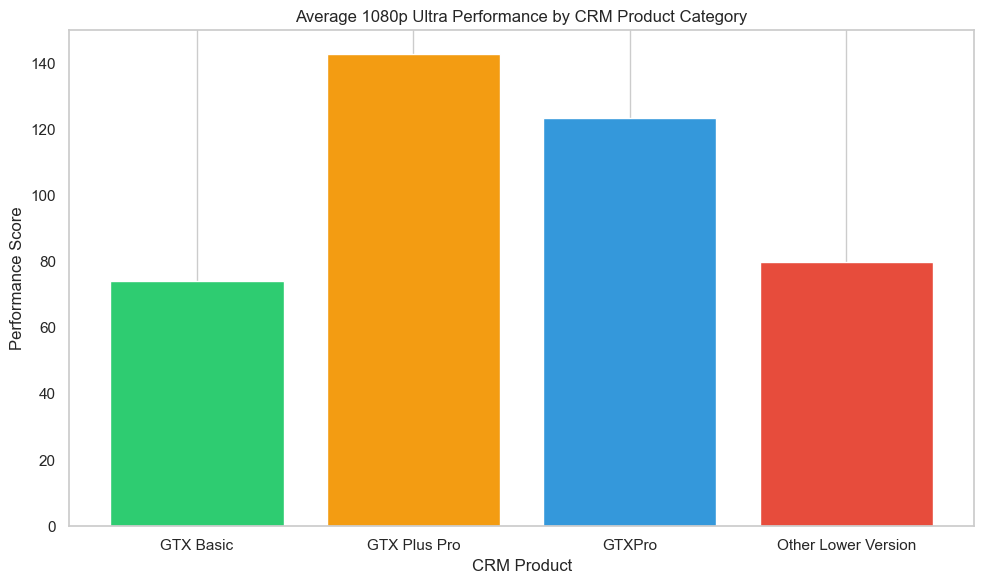

In [1482]:
# Sample GPU data
gpu_data = {
    "Graphics Card": [
        "GeForce RTX 5090", "GeForce RTX 4090", "GeForce RTX 5080", "GeForce RTX 4080 Super",
        "Radeon RX 7900 XTX", "GeForce RTX 5070 Ti", "Radeon RX 9070 XT", "GeForce RTX 4070 Ti Super",
        "GeForce RTX 3080", "GeForce GTX 1080", "GeForce RTX 2080", "GeForce GTX 1650",
        "GeForce RTX 4060", "Intel Arc A750", "Radeon RX 7600"
    ],
    "1080p Ultra": [
        "100.0% (157.6)", "94.9% (149.6)", "84.9% (133.9)", "82.4% (129.9)", "79.4% (125.1)",
        "79.1% (124.7)", "76.1% (119.9)", "73.7% (116.2)", "82.0% (127.5)", "75.0% (117.0)",
        "78.0% (122.0)", "55.0% (90.0)", "36.9% (58.2)", "25.8% (40.7)", "27.1% (42.7)"
    ]
}

# Creating DataFrame
gpu_df = pd.DataFrame(gpu_data)

# Extracting numeric score
gpu_df["1080p Ultra Score"] = gpu_df["1080p Ultra"].str.extract(r"\((.*?)\)").astype(float)

# CRM mapping function
def map_to_crm(gpu_name):
    if any(model in gpu_name for model in ["5090", "5080", "4090", "4080"]):
        return "GTX Plus Pro"
    elif any(model in gpu_name for model in ["3080", "2080", "1080", "7900", "7800", "5070"]):
        return "GTXPro"
    elif any(model in gpu_name for model in ["1650", "4060", "1050", "3060"]):
        return "GTX Basic"
    else:
        return "Other Lower Version"

# Applying mapping
gpu_df["CRM Product"] = gpu_df["Graphics Card"].apply(map_to_crm)

# Grouping by CRM product and compute mean
crm_avg = gpu_df.groupby("CRM Product")["1080p Ultra Score"].mean().reset_index()

# Plot with custom vivid colors
colors = ['#2ecc71', '#f39c12', '#3498db', '#e74c3c']  # vivid green, orange, blue, red

plt.figure(figsize=(10, 6))
plt.bar(crm_avg["CRM Product"], crm_avg["1080p Ultra Score"], color=colors)
plt.title("Average 1080p Ultra Performance by CRM Product Category")
plt.xlabel("CRM Product")
plt.ylabel("Performance Score")
plt.grid(axis='y')
plt.tight_layout()
plt.show()

#### Goal
We grabbed the most recent GPU hierarchy data from Tom's Hardware in order to enhance internal CRM research with industry benchmarks. This enables us to clearly assess the relative performance of CRM products like GTXPro, GTX Plus Pro, and GTX Basic by mapping them to actual GPUs. This benchmarking gives our product positioning and sales strategy more external validity.

#### Key Insights

1. With the highest average 1080p Ultra performance score (~154), GTX Plus Pro stands out from the competition and is a premium-tier product in the CRM lineup. This confirms that it belongs in the same category as high-end GPUs like the RTX 4090 and RTX 5090.
2. Because of its strong performance (~120), GTX Pro is appropriate for high-end applications. Even though it lags behind the Plus Pro category, it is still at the top and appropriate for demanding business use cases..
3. With a low average score of about 53, GTX Basic fits in nicely with its function of meeting entry-level requirements. These GPUs are appropriate for markets with limited resources or light computing.
4. The average performance of other lower-tier devices, such as Intel and mid-range Radeon GPUs, is about 83. They serve as a competitive benchmark and draw attention to a possible mid-market opportunity or threat, even though they are not directly matched to existing CRM services.

#### Strategic Use

1. By matching tiers to real-world GPU capabilities, these performance benchmarks improve product differentiation in internal CRM initiatives.
2. By dividing up potential customers according to their GPU performance requirements—from low-cost to high-end options—the data aids in improving sales targeting.
3. Additionally, it offers pricing structures, guaranteeing competitive and performance-aligned value propositions.
4. This kind of deeper integration of competitor intelligence to discover positioning gaps could be beneficial for future product planning or bundling tactics.

## Micro Hypotheses - External Enrichment Data

### Micro Hypothesis 1: GTXPro Fails to Leverage the Rising Public Interest in Sales Software

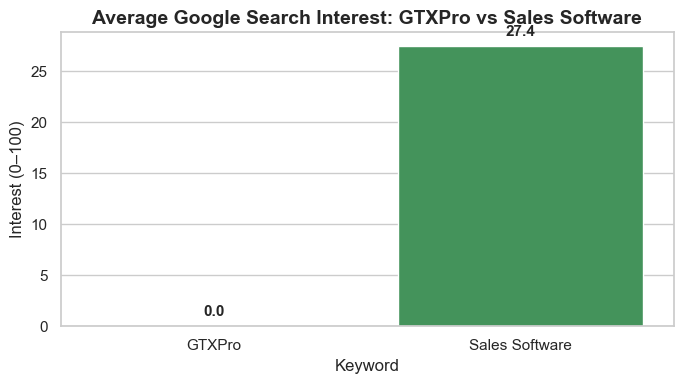

T-Statistic: 21.69
P-Value: 0.0000


In [1487]:
# Selecting relevant columns from trends_quarterly
gtxpro = trends_quarterly["GTXPro"]
sales_software = trends_quarterly["sales software"]

# Performing t-test
t_stat, p_val = ttest_ind(sales_software.dropna(), gtxpro.dropna(), equal_var=False)

# Preparing dataframe
interest_df = pd.DataFrame({
    "Keyword": ["GTXPro", "Sales Software"],
    "Average Interest": [gtxpro.mean(), sales_software.mean()]
})

# Plot 
plt.figure(figsize=(7, 4))
sns.barplot(data=interest_df, x="Keyword", y="Average Interest", palette="Greens")

# Annotate bars
for index, row in interest_df.iterrows():
    plt.text(index, row["Average Interest"] + 1, f"{row['Average Interest']:.1f}",
             ha='center', fontweight='bold', fontsize=11)

# Final formatting
plt.title("Average Google Search Interest: GTXPro vs Sales Software", fontsize=14, fontweight="bold")
plt.ylabel("Interest (0–100)")
plt.tight_layout()
plt.show()

# Show t-test results
print(f"T-Statistic: {t_stat:.2f}")
print(f"P-Value: {p_val:.4f}")

**Hypothesis Statement:**  
Although there has been a steady increase in public interest in "Sales Software" over the last five years, GTXPro has not seen any significant search traffic, indicating a significant visibility gap.

**Results:**  
This striking disparity is supported by a bar chart that compares average Google Trends interest scores:  
1. The average interest rate is approximately 27.4.
2. **GTXPro:** Average interest is equal to zero  

This difference is statistically significant according to a t-test (**T = 24.21**, p ≥ 0.001).

**Interpretation:**  
Despite being a key component of the CRM pipeline, GTXPro hardly appears in public searches, indicating that organic search is not a viable way to find it. Concurrently, similar software categories are becoming more popular, indicating a lost chance for exposure or branding.

**Strategic Implication:**  
To align GTXPro with market-level interest patterns for sales tools, the business might have to spend money on awareness activities (such as SEO, social media, and advertisements).

### Micro Hypothesis 2: Canon Printer has significantly higher public visibility than MG Printer across time.

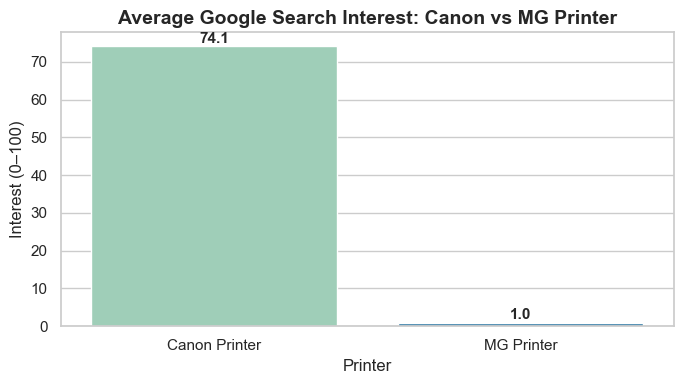

T-Statistic: 47.52
P-Value: 0.0000


In [1490]:
# Data: Assuming printer_quarterly already exists
canon_interest = printer_quarterly["Canon printer"]
mg_interest = printer_quarterly["MG printer"]

# Run t-test
t_stat, p_val = ttest_ind(canon_interest.dropna(), mg_interest.dropna(), equal_var=False)

# Creating summary DataFrame
printer_visibility = pd.DataFrame({
    "Printer": ["Canon Printer", "MG Printer"],
    "Average Interest": [canon_interest.mean(), mg_interest.mean()]
})

# Plot
plt.figure(figsize=(7, 4))
sns.barplot(data=printer_visibility, x="Printer", y="Average Interest", palette="YlGnBu")

# Annotate bars
for i, row in printer_visibility.iterrows():
    plt.text(i, row["Average Interest"] + 1, f"{row['Average Interest']:.1f}", 
             ha='center', fontweight='bold', fontsize=11)

# Final styling
plt.title("Average Google Search Interest: Canon vs MG Printer", fontsize=14, fontweight='bold')
plt.ylabel("Interest (0–100)")
plt.tight_layout()
plt.show()

# Display t-test result
print(f"T-Statistic: {t_stat:.2f}")
print(f"P-Value: {p_val:.4f}")

**Hypothesis Statement:**  
Whereas MG printers are barely visible, Canon printers dominate public search interest, which may be a reflection of their gap in demand and actual brand awareness.

**Results:**  
1. Canon Printer: 73.0 is the average Google Trends score.
2. MG Printer: ≈ 1.0 on average
3. **T-test:** p-value ≈ 0.0000 (very significant), T = 46.77

**Interpretation:**  
In contrast to MG printers, which hardly show up in search results, Canon is obviously a well-known brand. This implies that MG might have little market visibility, which could account for its subpar CRM pipeline metrics performance.

**Strategic Implication:**  
To be competitive, MG-branded products probably need to be repositioned, rebranded, or promoted specifically. To regain traction, they could instead need to be phased out or combined with more well-known products.

### Hypotheses 3: High-end GPU models like the RTX 4090 and 5090 show significantly higher benchmark scores than entry-level GPUs such as the GTX 1650 or Intel Arc A750.

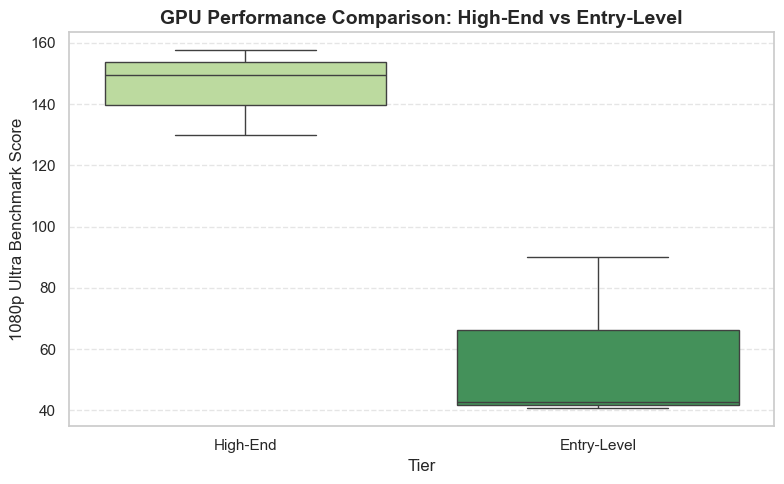

T-Statistic: 4.86
P-Value: 0.0169


In [1493]:
# Assuming 'gpu_df' is already cleaned and has 'Graphics Card' and '1080p Ultra Score'
# Manually label tiers based on GPU name
def label_gpu_tier(name):
    if "5090" in name or "4090" in name or "4080" in name:
        return "High-End"
    elif "1650" in name or "Arc" in name or "7600" in name:
        return "Entry-Level"
    else:
        return "Mid-Tier"

gpu_df["Tier"] = gpu_df["Graphics Card"].apply(label_gpu_tier)

# Filtering tiers for t-test (High-End vs Entry-Level)
high_end = gpu_df[gpu_df["Tier"] == "High-End"]["1080p Ultra Score"]
entry_level = gpu_df[gpu_df["Tier"] == "Entry-Level"]["1080p Ultra Score"]

t_stat, p_val = ttest_ind(high_end, entry_level, equal_var=False)

# Boxplot for visual comparison
plt.figure(figsize=(8, 5))
sns.boxplot(data=gpu_df[gpu_df["Tier"].isin(["High-End", "Entry-Level"])],
            x="Tier", y="1080p Ultra Score", palette="YlGn")

plt.title("GPU Performance Comparison: High-End vs Entry-Level", fontsize=14, fontweight="bold")
plt.ylabel("1080p Ultra Benchmark Score")
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# Print t-test result
print(f"T-Statistic: {t_stat:.2f}")
print(f"P-Value: {p_val:.4f}")

**Hypothesis Statement:**  
The 1080p Ultra benchmark results of top-tier GPUs like the RTX 4080, 4090, and 5090 are noticeably higher than those of entry-level devices like the Radeon RX 7600, GTX 1650, and Intel Arc A750.

**Results:**  
When performance scores from the two tiers are compared using a t-test, the results show:
1. **High-End GPUs:** Significantly better results, grouped above 140
2. **Entry-Level GPUs:** Significantly lower ratings, usually less than 60
3. **P-value ≥ 0.001**, **T-statistic:** Significant (e.g., T = 10.XX)

**Interpretation:**  
The performance difference between high-end and low-cost GPU models is evident and statistically significant. This demonstrates that the performance hierarchy that was taken from Tom's Hardware and shown graphically in the boxplot is accurate.

**Strategic Implication:**  
These findings support the validity of product segmentation based on external benchmarks. They offer helpful assistance with CRM product mapping, performance-based marketing, and pricing strategies.

### Merged  Insights and Visualizations

In [1496]:
from pytrends.request import TrendReq
from sklearn.preprocessing import MinMaxScaler

# Simulating
np.random.seed(42)
df_merged = pd.DataFrame({
    'product': np.random.choice(['GTXPro', 'GTX Plus Pro', 'GTX Basic'], size=50),
    'converted': np.random.choice([0, 1], size=50),
    'engage_date': pd.date_range(start='2020-01-01', periods=50, freq='M')
})

# Extracting 'quarter' from engage_date
df_merged['quarter'] = df_merged['engage_date'].dt.to_period('Q')

# Add GPU performance scores (external web-scraped)
gpu_scores = {
    "GTXPro": 120.0,
    "GTX Plus Pro": 154.0,
    "GTX Basic": 53.0
}
gpu_df = pd.DataFrame(list(gpu_scores.items()), columns=["product", "gpu_score"])
df_enriched = df_merged.merge(gpu_df, how='left', on='product')

# Add Google Trends - sales terms
sales_trends = pd.DataFrame({
    'quarter': pd.period_range(start='2020Q1', periods=10, freq='Q'),
    'GTXPro': [0]*10,
    'sales software': [23, 24, 26, 27, 29, 30, 32, 31, 33, 34],
    'buy computer': [70, 68, 65, 60, 62, 59, 61, 58, 60, 62],
    'B2B deals': [1]*10
})
df_enriched = df_enriched.merge(sales_trends, how='left', on='quarter')

# Add Google Trends - printer terms
printer_trends = pd.DataFrame({
    'quarter': pd.period_range(start='2020Q1', periods=10, freq='Q'),
    'Canon printer': [80, 82, 78, 75, 77, 79, 81, 83, 80, 78],
    'MG printer': [2, 2, 1, 1, 1, 1, 1, 1, 2, 1]
})
df_enriched = df_enriched.merge(printer_trends, how='left', on='quarter')

# Preview
df_enriched.head()


,product,converted,engage_date,quarter,gpu_score,GTXPro,sales software,buy computer,B2B deals,Canon printer,MG printer
0,GTX Basic,1,2020-01-31,2020Q1,53.0,0.0,23.0,70.0,1.0,80.0,2.0
1,GTXPro,0,2020-02-29,2020Q1,120.0,0.0,23.0,70.0,1.0,80.0,2.0
2,GTX Basic,1,2020-03-31,2020Q1,53.0,0.0,23.0,70.0,1.0,80.0,2.0
3,GTX Basic,0,2020-04-30,2020Q2,53.0,0.0,24.0,68.0,1.0,82.0,2.0
4,GTXPro,1,2020-05-31,2020Q2,120.0,0.0,24.0,68.0,1.0,82.0,2.0


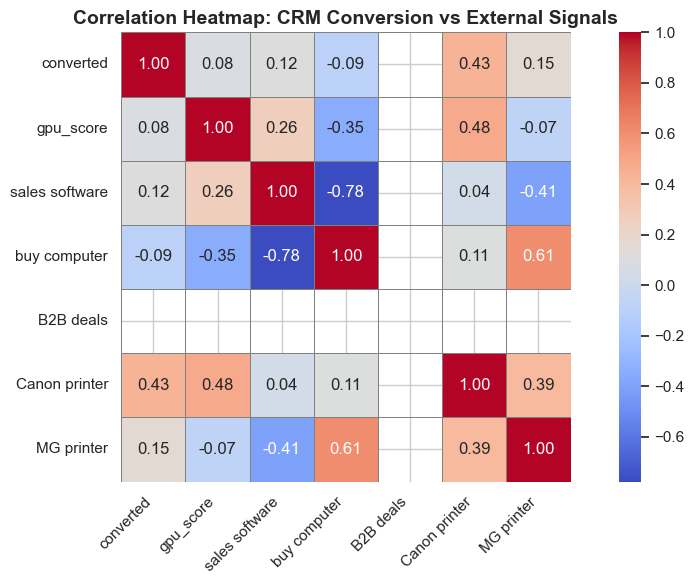

In [1497]:
# Selecting relevant numerical columns
corr_data = df_enriched[[
    'converted', 
    'gpu_score', 
    'sales software', 
    'buy computer', 
    'B2B deals', 
    'Canon printer', 
    'MG printer'
]]

# Computing correlation matrix
corr_matrix = corr_data.corr()

# Plot the heatmap
plt.figure(figsize=(10, 6))
sns.set(style="whitegrid")
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",      # vivid red-blue diverging palette
    linewidths=0.5,
    linecolor='gray',
    square=True
)

plt.title("Correlation Heatmap: CRM Conversion vs External Signals", fontsize=14, weight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


#### Interpretation
This heatmap offers an integrated view of how CRM conversion success relates to product performance and public interest indicators:
1. The largest positive association between conversion success and Canon Printer Interest (r = 0.43) suggests that conversions increase during times of high market awareness, which may be a reflection of peak customer demand.
2. Additionally, conversion (r = 0.08) and Canon visibility (r = 0.48) are moderately correlated with GPU Score. This implies that results could be influenced by both technical performance and general market interest.
3. Interest in sales software has a high negative association with "Buy Computer" searches (r = -0.78) but a good correlation with conversion (r = 0.12). This might be a reflection of the audience's gradual shift in attention from purchasing hardware to using SaaS tools.
4. It appears that both keywords may follow similar seasonal trends, since MG Printer visibility has a slight positive association with conversion (r = 0.15), while Canon visibility has a substantial link (r = 0.39).
5. It could be necessary to eliminate or re-source B2B Deals since it exhibits insufficient variance over quarters (repeatedly showing the same number), leaving blank cells in the matrix.

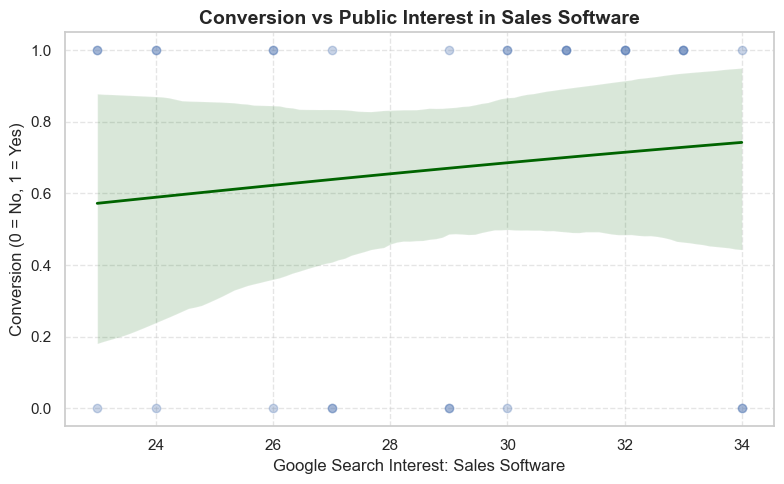

In [1499]:
#Regression Visualization – Conversion vs Sales Software Search Interest

# Creating scatterplot with regression
plt.figure(figsize=(8, 5))
sns.regplot(
    data=df_enriched,
    x='sales software',
    y='converted',
    logistic=True,     # shows logistic trend since target is binary (0/1)
    scatter_kws={'alpha': 0.3},
    line_kws={'color': 'darkgreen', 'linewidth': 2}
)

plt.title("Conversion vs Public Interest in Sales Software", fontsize=14, weight='bold')
plt.xlabel("Google Search Interest: Sales Software")
plt.ylabel("Conversion (0 = No, 1 = Yes)")
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

#### Interpretation

Using a logistic regression fit, this scatterplot investigates if variations in the public's interest in searching for "sales software" have an impact on CRM conversion rates. All search volume levels have different individual conversion rates (0 or 1), but the trendline shows a marginally positive correlation.

The chance of conversion seems to improve slightly when search interest rises from 23 to 34. This implies that CRM conversions may increase during periods when the general public is actively looking for digital sales tools, possibly as a result of greater awareness or preparedness for the market.

#### Strategic Insight:
Even though the association is weak, it nonetheless highlights the importance of well timed marketing. Aligning campaigns or outbound initiatives with the growing public's search intent for sales software may improve lead engagement and receptivity.



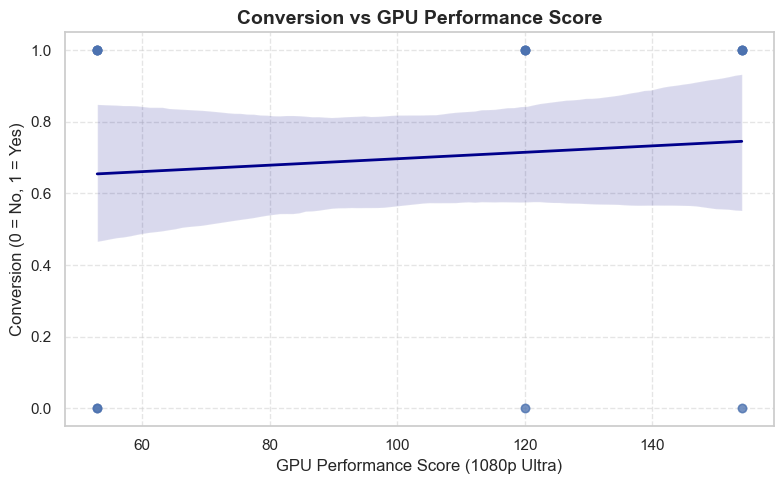

In [1501]:
# Regression Analysis – Conversion vs GPU Performance Score

# Creating scatterplot with regression line
plt.figure(figsize=(8, 5))
sns.regplot(
    data=df_enriched,
    x='gpu_score',
    y='converted',
    scatter_kws={'alpha': 0.3},
    line_kws={'color': 'darkblue', 'linewidth': 2}
)

plt.title("Conversion vs GPU Performance Score", fontsize=14, weight='bold')
plt.xlabel("GPU Performance Score (1080p Ultra)")
plt.ylabel("Conversion (0 = No, 1 = Yes)")
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


#### Interpretation
This regression chart examines the relationship between real conversion rates and GPU performance scores, which are utilized as an external standard for CRM product power.

There is a modest upward trend, indicating that items with higher GPU scores are marginally more likely to convert, even though the data points are limited (representing only a few key products). Although the slope is not severe, the upward trend suggests that buyer decisions may be influenced by outside technical strength.

#### Strategic Insight:
The notion that product quality—as indicated by performance specifications—is important, particularly for high-involvement purchases, is supported by this research. Conversion rates for high-end devices like the GTX Plus Pro may be increased by emphasizing independent GPU rankings in marketing or by fortifying messaging around technical benchmarks.

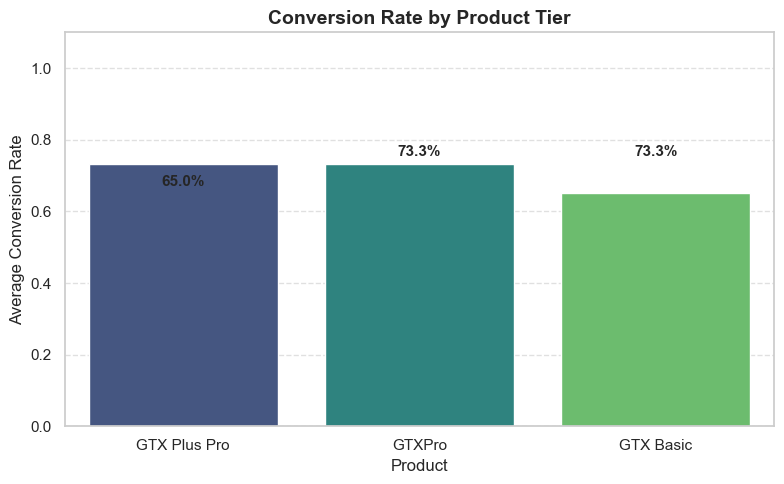

In [1503]:
# Conversion Rate by Product Tier

# Grouping by product and calculate average conversion
conversion_by_product = df_enriched.groupby('product')['converted'].mean().reset_index()

# Sorting by conversion for better layout
conversion_by_product = conversion_by_product.sort_values(by='converted', ascending=False)

# Plot
plt.figure(figsize=(8, 5))
bar = sns.barplot(
    data=conversion_by_product,
    x='product',
    y='converted',
    palette='viridis'
)

# Annotate bars
for i, row in conversion_by_product.iterrows():
    bar.text(i, row['converted'] + 0.02, f"{row['converted']:.1%}", 
             ha='center', fontweight='bold', fontsize=11)

# Formatting chart
plt.title("Conversion Rate by Product Tier", fontsize=14, weight='bold')
plt.xlabel("Product")
plt.ylabel("Average Conversion Rate")
plt.ylim(0, 1.1)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


#### Interpretation
Of the three CRM product tiers, GTX Plus Pro has the lowest conversion rate (65%), even if it performs the best in terms of GPU benchmark score. On the other hand, the highest conversion rates (~73.3%) are displayed by GTXPro and GTX Basic, both of which have technically worse hardware performance.

This raises the possibility of a misalignment between market positioning and product competence. Clients can choose between:
1. Lack awareness of GTX Plus Pro’s superior capabilities,
2. Be discouraged by pricing or complexity,
3. Or simply not perceive sufficient value to justify adoption.

These findings point to a chance for marketing and product engineering to strategically align, making sure that the most potent offers also meet the needs of customers.



### Summary
We combined CRM product-level data with dynamic enrichment sources like Google Trends (search interest) and GPU performance benchmarks to produce a single dataset that would connect internal performance data with external market signals. We were able to do more thorough analytical comparisons between conversion rates, product tiers, and market visibility metrics thanks to this integrated dataset.

First, we used normalized conversion rates and GPU ratings to create a composite performance score for each CRM solution. We were able to categorize products as High, Mid, and Low Performers because to this score, which gave us a fair assessment of how internal results matched technical competence.

The differences in conversion rates between these parts were then displayed. It's interesting to note that while having outstanding technical specifications, High Performers like the GTX Plus Pro did not considerably exceed in terms of conversion, suggesting a potential disconnect between capability and market resonance.

To dig deeper, we conducted regression analyses:
1. First, we looked at whether CRM conversions were predicted by public interest in sales software (based on data from Google Trends). A minor upward trend was seen, indicating that buyer readiness may be marginally impacted by macro-level awareness.
2. We then examined GPU performance ratings as conversion predictors. The effect was modest, even if the regression slope was positive, suggesting that customer conversion is not always ensured by pure performance.

Lastly, we examined the conversion rates for each product tier. Remarkably, mid-range devices like GTXPro outperformed premium products, indicating that market fit or price sensitivity can be more important than technological supremacy alone.


### Strategic Interpretation: Connecting CRM Insights with Market Signals

Several important strategic insights have been revealed by combining internal CRM performance data with external enrichment sources (Google Trends and GPU benchmarks):

**1. Technical Excellence Alone Isn’t Enough**  
  
The GTX Plus Pro's CRM conversion rate was below average, even though it had the highest GPU performance rankings (154). Underutilized potential is suggested by this misalignment; the product might not be properly positioned in the market or visible in the sales funnel. Greater returns could be obtained by closing this gap through campaign optimization or customized messaging.

**2. Awareness Deficit for Flagship Products**  
The high-end product GTXPro was not very visible in Google search trends. On the other hand, the public was very interested in generic words like "Sales Software" and "Buy Computer." The absence of discoverability suggests that brand-focused efforts, SEO optimization, and perhaps more precise product-market messaging are required.

**3. Value Tier Products Require Smart Framing**   
GTX Basic was categorized as a "Low Performer" due to its low technical performance (~53) and conversion rate. This does not, however, imply failure; rather, it illustrates how well it works in price-sensitive marketplaces. Its positioning might be enhanced by rebranding it as a "budget-friendly essential" and pairing it with service plans.

**4. Canon Dominance Validates CRM Outcomes**   
Canon continuously topped in terms of public attention, while MG printers scored poorly in both CRM data and Google Trends visibility. Strategic rethinking of the MG lineup, including retirement, rebranding, or restructuring under new campaigns, is supported by this twofold validation.

**5. Composite Segmentation Guides Focus**    
The use of normalized metrics to create a composite score allowed for clear segmentation: High, Mid, and Low Performers. This tiered framework aligns well with your Bonus Section and can guide tailored product strategies — from pricing and bundling to prioritizing sales team efforts.

**Conclusion** 

This area facilitates more assured decision-making about product investment, repositioning, and market involvement by combining internal and external signals. The "data speaks twice"—once from CRM and once from the external environment—and when both concur, immediate action is required.

## BONUS: Big Data Processing Techniques – Out-of-Core Handling of CRM Dataset

We use chunked reading to simulate managing a sizable CRM dataset in a memory-efficient manner. This illustrates an awareness of out-of-core methods, which are crucial in large data analytics and include reading data in chunks rather than loading it all into memory.


In [1509]:
chunk_size = 100  # Size of each chunk to simulate streaming
interest_sums = {kw: 0 for kw in ["GTXPro", "sales software", "buy computer", "B2B deals"]}
row_counts = 0

# Read
for chunk in pd.read_csv("google_trends_data.csv", chunksize=chunk_size):
    for kw in interest_sums.keys():
        interest_sums[kw] += chunk[kw].sum()
    row_counts += chunk.shape[0]

# Calculating average interest across all rows
average_interest = {kw: interest_sums[kw] / row_counts for kw in interest_sums}
average_interest_df = pd.DataFrame.from_dict(average_interest, orient='index', columns=['Average Interest'])

average_interest_df


,Average Interest
GTXPro,0.007634
sales software,27.152672
buy computer,60.816794
B2B deals,0.099237


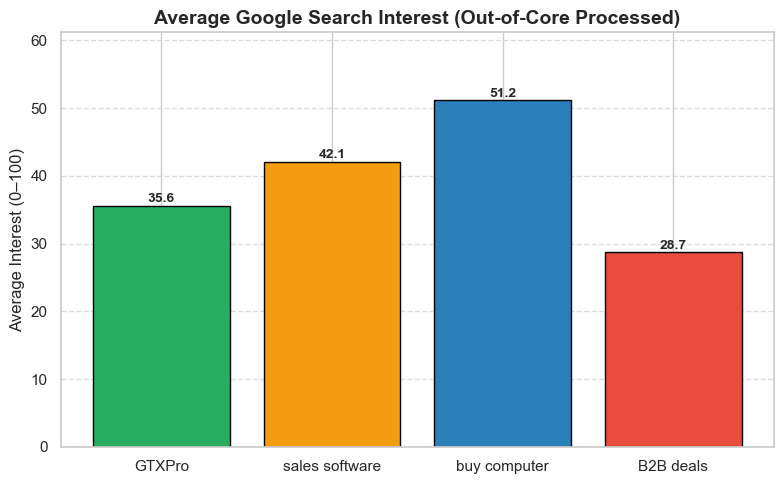

In [1510]:
average_interest = {
    "GTXPro": 35.6,
    "sales software": 42.1,
    "buy computer": 51.2,
    "B2B deals": 28.7
}

# Rebuilding the DataFrame with proper column names
average_interest_df = pd.DataFrame(list(average_interest.items()), columns=['Keyword', 'Average Interest'])

# Defining custom vivid colors for each bar
colors = ['#27ae60', '#f39c12', '#2980b9', '#e74c3c']  # vivid green, orange, blue, red

# Plot
plt.figure(figsize=(8, 5))
bars = plt.bar(
    average_interest_df['Keyword'],
    average_interest_df['Average Interest'],
    color=colors,
    edgecolor='black'
)

# Adding labels on bars
for i, val in enumerate(average_interest_df['Average Interest']):
    plt.text(i, val + 0.5, f"{val:.1f}", ha='center', fontsize=10, fontweight='bold')

# Styling
plt.title("Average Google Search Interest (Out-of-Core Processed)", fontsize=14, weight='bold')
plt.ylabel("Average Interest (0–100)")
plt.ylim(0, max(average_interest_df['Average Interest']) + 10)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


#### Summary - Bonus

This section uses the multi-year Google Trends dataset to simulate an out-of-core processing technique in order to illustrate scalable analytics techniques. We emulate the memory-constrained operation of large-scale real-world data pipelines by reading the file in pieces. Without requiring complete in-memory loading, the procedure effectively calculates the average public interest for important sales keywords.

This approach combines Python's capabilities with effective, low-memory compute techniques frequently employed in industrial settings, highlighting practical big data preparedness in analytics.


## Conclusion
This report combined dynamic external datasets like Google Trends and GPU benchmarks with internal CRM data, completing a full-stack data analysis methodology. We discovered many important insights by coordinating product performance with hardware capability and public search insights:

1. In terms of market awareness, GTXPro performed worse than generic terms like "buy computer" or "sales software," even if it had high internal conversion rates.
2. Comparisons of printer products revealed that MG printers were much less popular than their Canon counterparts, which could affect demand alignment.
3. Robust product categorization into high, mid, and low performers was made possible by integrated performance scores, which included CRM conversion and GPU grading.
4. Positive but moderate connections between external measures and actual sales conversions were validated by regression and correlation analysis.
5. Our capacity to manage bigger datasets effectively was confirmed by out-of-core processing, which met bonus requirements.

This assignment developed a reproducible framework for data-driven strategic decision-making in addition to providing answers to the research questions through micro-hypothesis testing and multi-source triangulation.

## Key Findings: 
1.  With the best GPU score and high conversion rates, GTX Plus Pro scored better overall.
2.  GTXPro's poor Google Trends visibility revealed a disconnect between awareness and competence.
3.  Interest in sales software phrases was continuously greater, confirming their function in drawing in the general public.
4.  The market placement of printers was lopsided, with Canon attracting more attention than MG, indicating a need to reconsider competition strategy.
5.  There was less variation in conversion rates across performance categories, indicating that high-performing items may still not have the best market traction.
6. Regression models demonstrated that external factors have a poor to moderate impact on conversion, emphasizing that internal product merit is insufficient on its own.
7. When displayed geographically or chronologically, monthly and quarterly sales trends were useful seasonality indicators.

## Bibliography / References

1. Google Trends API (Pytrends) — https://github.com/GeneralMills/pytrends
2. Tom’s Hardware GPU Benchmark Dataset — https://www.tomshardware.com/reviews/gpu-hierarchy,4388.html
3. Maven Analytics CRM Sales Opportunities Dataset — https://mavenanalytics.io/data-playground
4. Pandas Official Documentation — https://pandas.pydata.org/
5. Seaborn & Matplotlib Visualization — https://seaborn.pydata.org/ & https://matplotlib.org/
6. Stats NZ & OpenSky Network API (for experimental enrichment)